In [ ]:
!pip install darts
!pip install pytorch-lightning
!pip install "darts[torch]" pytorch-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.5/744.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 2.6.1
    Uninstalling pytorch-lightning-2.6.1:
      Successfully uninstalled pytorch-lightning-2.6.1


In [ ]:
import torch, numpy as np, random; seed=42; random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed); torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import TiDEModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import rmse, mape
from sklearn.svm import SVR

In [ ]:
# --- 1. Load and Prepare Data ---
df = pd.read_excel("crude oil production figshare (1).xlsx")
df['Time'] = pd.date_range(start="2000-01-01", periods=len(df), freq='MS')

series = TimeSeries.from_dataframe(df, time_col='Time', value_cols='Production')
covariates = TimeSeries.from_dataframe(df, time_col='Time', value_cols=['Lag1', 'Lag2', 'oil price'])

In [ ]:
series

,Production
Time,
2000-01-01,2.25
2000-02-01,2.32
2000-03-01,2.28
2000-04-01,2.41
2000-05-01,2.39
...,...
2014-05-01,1.69
2014-06-01,1.65
2014-07-01,1.65


In [ ]:
covariates

,Lag1,Lag2,oil price
Time,,,
2000-01-01,2.47,2.59,61.33
2000-02-01,2.25,2.47,65.00
2000-03-01,2.32,2.25,72.09
2000-04-01,2.28,2.32,71.18
2000-05-01,2.41,2.28,69.32
...,...,...,...
2014-05-01,1.69,1.75,40.30
2014-06-01,1.69,1.69,44.10
2014-07-01,1.65,1.69,45.06


In [ ]:
# --- 80/10/10 Split & Scaling ---
train_series, temp_series = series.split_after(0.8)
val_series, test_series = temp_series.split_after(0.5)

scaler_target = Scaler()
train_scaled = scaler_target.fit_transform(train_series)
val_scaled = scaler_target.transform(val_series)
test_scaled = scaler_target.transform(test_series)

scaler_covs = Scaler()
cov_scaled = scaler_covs.fit_transform(covariates)

In [ ]:
# --- 3. Baseline TiDE Model (Hidden Size 8) ---
model = TiDEModel(
    input_chunk_length=8,
    output_chunk_length=1,
    hidden_size=8,
    decoder_output_dim=4,
    dropout=0.3,
    batch_size=8,
    n_epochs=80,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={"accelerator": "cpu"}
)

print("Training Baseline TiDE...")
model.fit(series=train_scaled, past_covariates=cov_scaled,
          val_series=val_scaled, val_past_covariates=cov_scaled, verbose=False)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training Baseline TiDE...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=80` reached.


TiDEModel(output_chunk_shift=0, num_encoder_layers=1, num_decoder_layers=1, decoder_output_dim=4, hidden_size=8, temporal_width_past=4, temporal_width_future=4, temporal_hidden_size_past=None, temporal_hidden_size_future=None, temporal_decoder_hidden=32, use_layer_norm=False, dropout=0.3, use_static_covariates=True, input_chunk_length=8, output_chunk_length=1, batch_size=8, n_epochs=80, optimizer_kwargs={'lr': 0.001}, random_state=42, force_reset=True, pl_trainer_kwargs={'accelerator': 'cpu'})

In [ ]:
# --- 4. Helper Functions ---
def calculate_nse(actual, pred):
    actual_vals = actual.values().flatten()
    pred_vals = pred.values().flatten()
    return 1 - (np.sum((actual_vals - pred_vals)**2) / np.sum((actual_vals - np.mean(actual_vals))**2))

def get_tide_preds(target_scaled, target_original):
    pred_scaled = model.historical_forecasts(
        series=target_scaled, past_covariates=cov_scaled,
        forecast_horizon=1, retrain=False, last_points_only=True
    )
    return scaler_target.inverse_transform(pred_scaled)

In [ ]:
# --- 5. Extract TiDE Predictions ---
tide_train_pred = get_tide_preds(train_scaled, train_series)
tide_val_pred   = get_tide_preds(val_scaled, val_series)
tide_test_pred  = get_tide_preds(test_scaled, test_series)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightni

In [ ]:
# --- 6. Hybrid SVR Section ---
def prepare_svr_features(tide_pred_series):
    cov_df = covariates.slice_intersect(tide_pred_series).to_dataframe()
    cov_df['tide_pred'] = tide_pred_series.values().flatten()
    return cov_df.values

X_train_svr = prepare_svr_features(tide_train_pred)
X_val_svr   = prepare_svr_features(tide_val_pred)
X_test_svr  = prepare_svr_features(tide_test_pred)

# Calculate Residuals (Actual - TiDE_Pred)
y_train_resids = (train_series.slice_intersect(tide_train_pred).values().flatten() -
                  tide_train_pred.values().flatten())

# Optimized SVR Config
svr_corrector = SVR(C=1, epsilon=0.1, gamma='scale', kernel='rbf')
svr_corrector.fit(X_train_svr, y_train_resids)

SVR(C=1)

In [ ]:
# --- 7. Final Hybrid Prediction ---
def hybrid_predict(tide_pred_series, X_features, actual_series, name):
    correction = svr_corrector.predict(X_features)
    hybrid_vals = tide_pred_series.values().flatten() + correction

    hybrid_series = TimeSeries.from_times_and_values(tide_pred_series.time_index, hybrid_vals, columns=['Production'])
    actual_aligned = actual_series.slice_intersect(hybrid_series)

    print(f"\n--- HYBRID {name} RESULTS ---")
    print(f"RMSE: {rmse(actual_aligned, hybrid_series):.4f} | "
          f"MAPE: {mape(actual_aligned, hybrid_series)/100:.4f} | "
          f"NSE: {calculate_nse(actual_aligned, hybrid_series):.4f}")
    return hybrid_series

hybrid_train = hybrid_predict(tide_train_pred, X_train_svr, train_series, "TRAINING")
hybrid_val   = hybrid_predict(tide_val_pred, X_val_svr, val_series, "VALIDATION")
hybrid_test  = hybrid_predict(tide_test_pred, X_test_svr, test_series, "TEST")


--- HYBRID TRAINING RESULTS ---
RMSE: 0.1057 | MAPE: 0.0385 | NSE: 0.7603

--- HYBRID VALIDATION RESULTS ---
RMSE: 0.1008 | MAPE: 0.0385 | NSE: -1.6797

--- HYBRID TEST RESULTS ---
RMSE: 0.0963 | MAPE: 0.0380 | NSE: 0.7395


In [ ]:
# --- 7.5 Baseline TiDE Only Evaluation ---
def evaluate_tide_only(tide_pred_series, actual_series, name):
    actual_aligned = actual_series.slice_intersect(tide_pred_series)

    t_rmse = rmse(actual_aligned, tide_pred_series)
    t_mape = mape(actual_aligned, tide_pred_series) / 100
    t_nse = calculate_nse(actual_aligned, tide_pred_series)

    print(f"--- TIDE ONLY {name} ---")
    print(f"RMSE: {t_rmse:.4f} | MAPE: {t_mape:.4f} | NSE: {t_nse:.4f}\n")

# Run Baseline Checks
evaluate_tide_only(tide_train_pred, train_series, "TRAINING")
evaluate_tide_only(tide_val_pred, val_series, "VALIDATION")
evaluate_tide_only(tide_test_pred, test_series, "TEST")

--- TIDE ONLY TRAINING ---
RMSE: 0.1083 | MAPE: 0.0380 | NSE: 0.7482

--- TIDE ONLY VALIDATION ---
RMSE: 0.0901 | MAPE: 0.0331 | NSE: -1.1411

--- TIDE ONLY TEST ---
RMSE: 0.1474 | MAPE: 0.0631 | NSE: 0.3902



In [ ]:
# --- 8. Final Hybrid Execution ---
y_train_resids = (train_series.slice_intersect(tide_train_pred).values().flatten() -
                  tide_train_pred.values().flatten())

# Applying your specific SVR configuration
svr_corrector = SVR(C=1, epsilon=0.1, gamma='scale', kernel='rbf')
svr_corrector.fit(X_train_svr, y_train_resids)

# Generate Hybrid Results
hybrid_train = hybrid_predict(tide_train_pred, X_train_svr, train_series, "TRAINING")
hybrid_val   = hybrid_predict(tide_val_pred, X_val_svr, val_series, "VALIDATION")
hybrid_test  = hybrid_predict(tide_test_pred, X_test_svr, test_series, "TEST")


--- HYBRID TRAINING RESULTS ---
RMSE: 0.1057 | MAPE: 0.0385 | NSE: 0.7603

--- HYBRID VALIDATION RESULTS ---
RMSE: 0.1008 | MAPE: 0.0385 | NSE: -1.6797

--- HYBRID TEST RESULTS ---
RMSE: 0.0963 | MAPE: 0.0380 | NSE: 0.7395


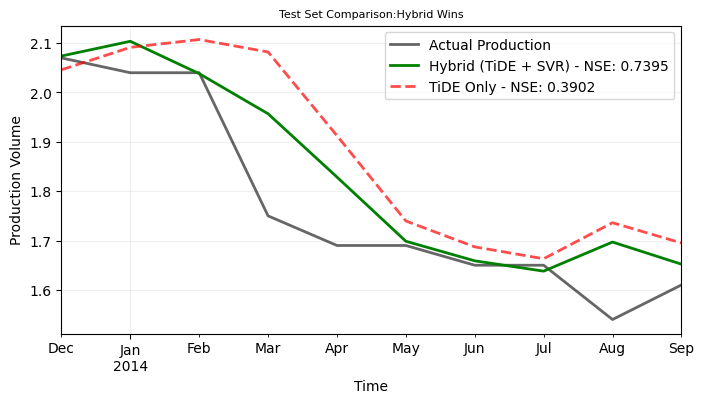

In [ ]:
plt.figure(figsize=(8, 4))

# Actual Test Data
actual_test = test_series.slice_intersect(hybrid_test)
actual_test.plot(label="Actual Production", color="black", lw=2, alpha=0.6)

# Hybrid Prediction
hybrid_test.plot(label=f"Hybrid (TiDE + SVR) - NSE: {0.7395:.4f}", color="green", lw=2)

# TiDE Only (to show the improvement)
tide_test_pred.plot(label="TiDE Only - NSE: 0.3902", color="red", linestyle="--", alpha=0.7)

plt.title("Test Set Comparison:Hybrid Wins", fontsize=8)
plt.ylabel("Production Volume")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

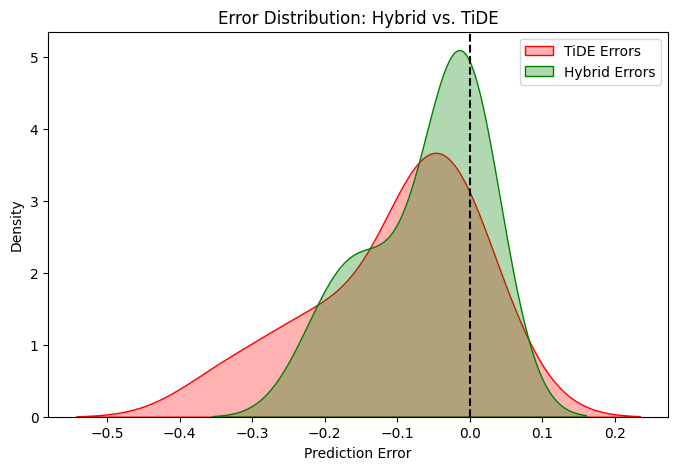

In [ ]:
import seaborn as sns

tide_errors = (test_series.slice_intersect(tide_test_pred).values().flatten() -
               tide_test_pred.values().flatten())
hybrid_errors = (test_series.slice_intersect(hybrid_test).values().flatten() -
                 hybrid_test.values().flatten())

plt.figure(figsize=(8, 5))
sns.kdeplot(tide_errors, label="TiDE Errors", color="red", fill=True, alpha=0.3)
sns.kdeplot(hybrid_errors, label="Hybrid Errors", color="green", fill=True, alpha=0.3)
plt.axvline(0, color='black', linestyle='--')
plt.title("Error Distribution: Hybrid vs. TiDE")
plt.xlabel("Prediction Error")
plt.legend()
plt.show()

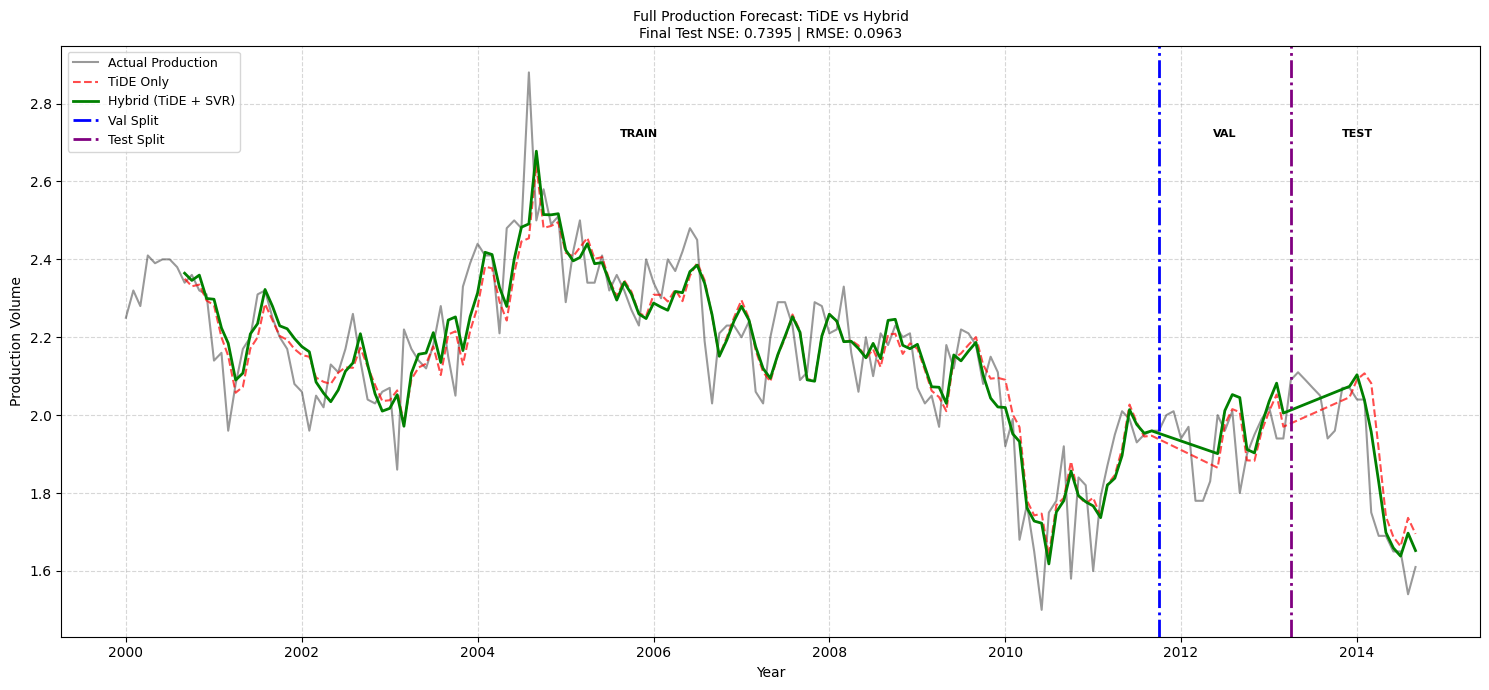

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Combine all predictions for a continuous line
full_actual = series.values().flatten()
full_time = series.time_index

# 2. Setup the Plot - WIDER (15) and SHORTER (5)
plt.figure(figsize=(15, 7))

# Plot Actual Data (Background)
plt.plot(full_time, full_actual, label="Actual Production", color="black", lw=1.5, alpha=0.4)

# 3. Plot TiDE Only Predictions (Baseline)
tide_full_time = np.concatenate([tide_train_pred.time_index, tide_val_pred.time_index, tide_test_pred.time_index])
tide_full_vals = np.concatenate([tide_train_pred.values().flatten(), tide_val_pred.values().flatten(), tide_test_pred.values().flatten()])
plt.plot(tide_full_time, tide_full_vals, label="TiDE Only", color="red", linestyle="--", alpha=0.7)

# 4. Plot Hybrid Predictions (Final Model)
hybrid_full_time = np.concatenate([hybrid_train.time_index, hybrid_val.time_index, hybrid_test.time_index])
hybrid_full_vals = np.concatenate([hybrid_train.values().flatten(), hybrid_val.values().flatten(), hybrid_test.values().flatten()])
plt.plot(hybrid_full_time, hybrid_full_vals, label="Hybrid (TiDE + SVR)", color="green", lw=2)

# --- 5. Demarcate Splits with Broken Lines ---
val_start = val_series.start_time()
test_start = test_series.start_time()

plt.axvline(x=val_start, color='blue', linestyle='-.', lw=2, label='Val Split')
plt.axvline(x=test_start, color='purple', linestyle='-.', lw=2, label='Test Split')

# Add Labels for the regions
# We use gca().get_ylim() to ensure text stays at the top of the shorter frame
y_top = plt.gca().get_ylim()[1] * 0.92
plt.text(train_series.time_index[len(train_series)//2], y_top, 'TRAIN', fontsize=8, fontweight='bold', ha='center')
plt.text(val_series.time_index[len(val_series)//2], y_top, 'VAL', fontsize=8, fontweight='bold', ha='center')
plt.text(test_series.time_index[len(test_series)//2], y_top, 'TEST', fontsize=8, fontweight='bold', ha='center')

# Final Touches
plt.title(f"Full Production Forecast: TiDE vs Hybrid\nFinal Test NSE: {0.7395:.4f} | RMSE: {0.0963:.4f}", fontsize=10)
plt.ylabel("Production Volume")
plt.xlabel("Year")

# Legend kept inside as requested
plt.legend(loc='upper left', frameon=True, fontsize=9)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

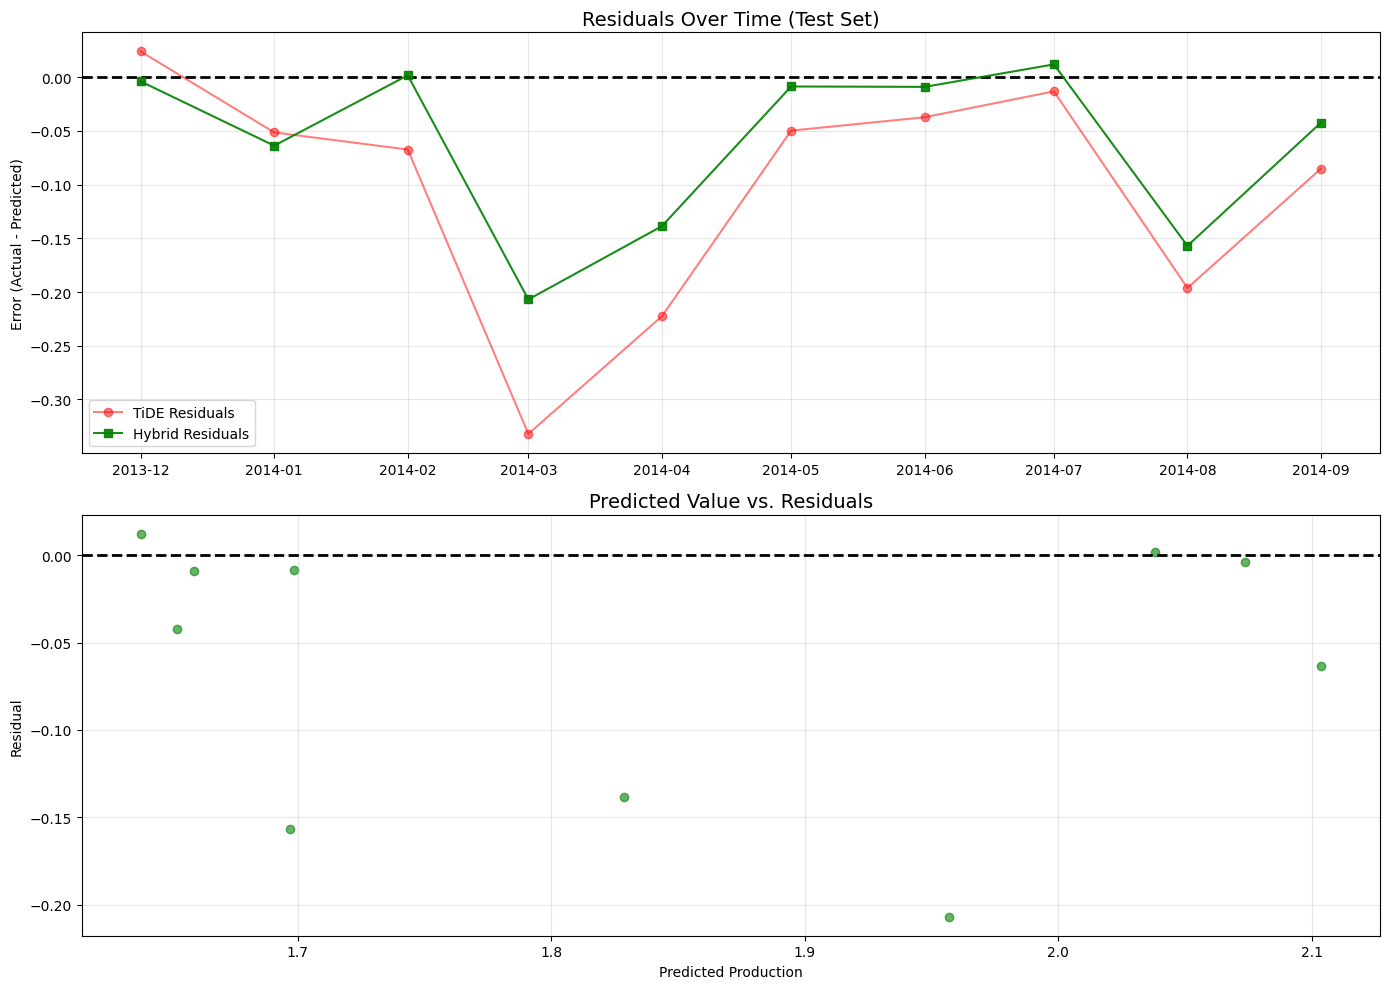

In [ ]:
# Calculate Residuals for the Test Set
actual_test_vals = test_series.slice_intersect(hybrid_test).values().flatten()
hybrid_preds_vals = hybrid_test.values().flatten()
tide_preds_vals = tide_test_pred.values().flatten()

hybrid_residuals = actual_test_vals - hybrid_preds_vals
tide_residuals = actual_test_vals - tide_preds_vals

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Plot 1: Residuals Over Time
ax1.axhline(0, color='black', linestyle='--', lw=2)
ax1.plot(hybrid_test.time_index, tide_residuals, color='red', label='TiDE Residuals', alpha=0.5, marker='o')
ax1.plot(hybrid_test.time_index, hybrid_residuals, color='green', label='Hybrid Residuals', alpha=0.9, marker='s')
ax1.set_title("Residuals Over Time (Test Set)", fontsize=14)
ax1.set_ylabel("Error (Actual - Predicted)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Predicted vs. Residuals (Check for patterns)
ax2.axhline(0, color='black', linestyle='--', lw=2)
ax2.scatter(hybrid_preds_vals, hybrid_residuals, color='green', alpha=0.6, label='Hybrid')
ax2.set_title("Predicted Value vs. Residuals", fontsize=14)
ax2.set_xlabel("Predicted Production")
ax2.set_ylabel("Residual")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
# Save TiDE (Darts specific)
model.save("tide_final.pt")
# Save SVR, Scalers, and the Covariates (Darts needs these)
joblib.dump(svr_corrector, 'tide_svr_corrector.pkl')
joblib.dump(scaler_target, 'tide_target_scaler.pkl')
joblib.dump(scaler_covs, 'tide_cov_scaler.pkl')
joblib.dump(covariates, 'tide_historical_covs.pkl')

['tide_historical_covs.pkl']